# Linear regression from scratch

In [29]:
import numpy as np
# from sklearn.datasets import load_boston
import matplotlib.pyplot as plt
import pandas as pd

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [30]:
X = data
y = target[:,np.newaxis] # make array with labels 2D

print("Total samples in our dataset is: {}".format(X.shape[0]))

Total samples in our dataset is: 506


In [31]:
# sum of squared errors is the cost functions
def compute_cost(X, y, params):
    n_samples = len(y)
    h = X @ params # inner product of features with parameters
    
    # sum squares of errors, divide by number of samples to get average, times by 1/2 for mathematical convenience when taking derivatives
    return (1/(2*n_samples))*np.sum((h-y)**2) 

## Gradient descent algorithm
Used to iteratively find the minimum of a function.

We have the cost (error) function:
$$ J(\theta) = \frac{1}{2n} \sum_{i=1}^{n} (h_i - y_i)^2 $$
where $\theta$ is the parameters of the model. This is the mathematical representation of the `compute_cost()` function. 

We want to find $\theta$ that minimises the cost function. 

1. Start with initial guess for $\theta$ (often zeros or random values).
2. Compute the gradient of the cost function with respect to $\theta$:
$$
\nabla_\theta J(\theta) = \frac{1}{n} X^T (X \theta - y)
$$
- this tells you the direction of steepest ascent of $J$.
- $X \theta$ is just the inner product of the features with the parameters, like we found in the `compute_cost()` function
- I have no clue how this gradient is calculated. I hope it doesn't matter
3. Move $\theta$ in the opposite direction of the gradient (because we want to minimize, not maximize):
$$
\theta := \theta - \alpha \cdot \nabla_\theta J(\theta)
$$
- $\alpha$ = learning rate → controls step size.
- repeat until convergence (gradient is near zero or cost stops decreasing).

In [32]:
def gradient_descent(X, y, params, learning_rate, n_iters):
    n_samples = len(y)
    # keep a history of costs
    J_history = np.zeros((n_iters,1))

    for i in range(n_iters):
        # implements the gradient descent update rule, see the formulae in step 2 and 3 above
        params = params - (learning_rate/n_samples) * X.T @ (X @ params - y) 
        J_history[i] = compute_cost(X, y, params)

    return (J_history, params)

## Normalisation
Before running the algorithm on the dataset, it should be normalised to boost accuracy while lowering cost (error). Normalisation also prevents features with large ranges from dominating the learning process. 

Each feature is normalised to have mean = 0, and standard deviation = 1. This is achieved by applying the following formula to each element $X_{ij}$:
$$ X_{ij} := \frac{X_{ij} - {\mu}_j}{{\sigma}_j} $$

This just means for each element, subtract the mean of the feature, and divide by the standard deviation of the feature. 

In [33]:
n_samples = len(y)

# 2nd arg 0 tells function to operate along columuns, i.e. find mean and standard deviation of features (rather than samples)
mu = np.mean(X, 0)
sigma = np.std(X, 0)

X = (X-mu) / sigma

# creates a column vector of ones with shape (n_samples, 1), horizontally stacks this column with the feature matrix X
# the 1s allow the bias/intercept term to be treated like any other parameter in matrix multiplication:
X = np.hstack((np.ones((n_samples,1)),X))

# count the number of columns/features (includes the column of 1s)
n_features = np.size(X,1)

# initialise parameters for all features to 0
params = np.zeros((n_features,1))

Initial cost is:  296.0734584980237 

Optimal parameters are: 
 [[22.53279993]
 [-0.83980839]
 [ 0.92612237]
 [-0.17541988]
 [ 0.72676226]
 [-1.82369448]
 [ 2.78447498]
 [-0.05650494]
 [-2.96695543]
 [ 1.80785186]
 [-1.1802415 ]
 [-1.99990382]
 [ 0.85595908]
 [-3.69524414]] 

Final cost is:  [11.00713381]


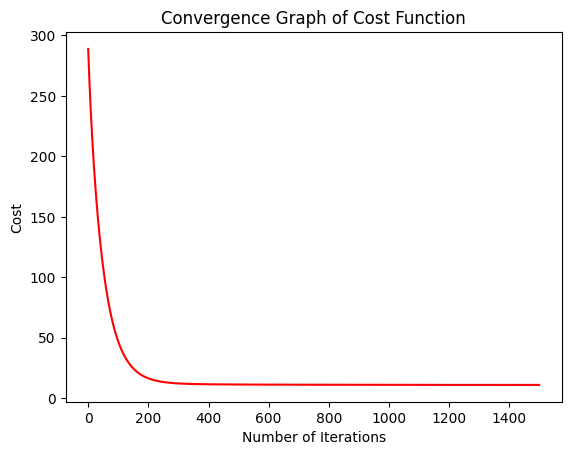

In [34]:
n_iters = 1500
learning_rate = 0.01

initial_cost = compute_cost(X, y, params)

print("Initial cost is: ", initial_cost, "\n")

(J_history, optimal_params) = gradient_descent(X, y, params, learning_rate, n_iters)

print("Optimal parameters are: \n", optimal_params, "\n")

print("Final cost is: ", J_history[-1])

plt.plot(range(len(J_history)), J_history, 'r')

plt.title("Convergence Graph of Cost Function")
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.show()